# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [79]:
# Load the libraries as required.
import pandas as pd
import os


In [80]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()

#Preview data
print(fires_dt.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB
   coord_x  coord_y month  day  ffmc   dmc     dc  isi  temp  rh  wind  rain  \
0        7        5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0   
1        7        4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0   
2        7        4   

# Get X and Y

Create the features data frame and target data.

In [86]:
# Define the feature 
X = fires_dt.drop(columns=['area'], axis=1)

# Define the target variable
y = fires_dt['area']

# Print the shapes of features and target variable
print(X.shape)
print(y.shape)


(517, 12)
(517,)


In [90]:
# Create train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print( X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(413, 12)
(104, 12)
(413,)
(104,)


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


In [91]:
#fires_dt.info()

# Define feature lists
numeric_features = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
categorical_features = ['month', 'day']

In [ ]:
#Import libraries
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Create Preproc 1
preproc1 = ColumnTransformer(
    transformers=[
    ('num', StandardScaler(), numeric_features), #Use standard scaler for numeric features
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features) #Use one-hot encoder for categorical features
])


### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [ ]:
#Import libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Create Preproc 2
preproc2 = ColumnTransformer(transformers=[
        # Numeric features pipeline: power transformation + scaling
        ('num', Pipeline([
        ('power', PowerTransformer(method='yeo-johnson')),  #Non-linear transformation
        ('scaler', StandardScaler()) #Scaling
    ]), numeric_features),
        # Categorical feathures: one-hot encoding
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])


## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [130]:
# Pipeline A = preproc1 + baseline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score, KFold
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Define Pipeline A with updated preproc1
pipeline_a = Pipeline(steps=[('preprocessing', preproc1),
    ('regressor', LinearRegression())
])

# Define 5-Fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
scores_a = cross_val_score(
    pipeline_a,
    X, y,
    scoring='neg_root_mean_squared_error',
    cv=cv
)

print("Pipeline A LinearRegression scores:", scores_a)
print("Mean RMSE:", np.mean(scores_a))


Pipeline A LinearRegression scores: [-107.76675987  -37.79552434  -28.16019558  -77.39846971  -27.10438145]
Mean RMSE: -55.645066190794374


In [131]:
# Pipeline B = preproc2 + baseline

pipeline_b = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', Ridge())
])

# Define 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate using cross-validation
scores_b = cross_val_score(
    pipeline_b,
    X, y,
    scoring='neg_root_mean_squared_error',
    cv=cv
)

print("Pipeline B Ridge scores:", scores_b)
print("Mean RMSE:", np.mean(scores_b))


Pipeline B Ridge scores: [-107.89094877  -37.93138402  -28.23670185  -77.16155606  -26.14874838]
Mean RMSE: -55.47386781531986


In [133]:
# Pipeline C = preproc2 + advanced model
from sklearn.neural_network import MLPRegressor

pipeline_c = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', MLPRegressor(random_state=42, max_iter=1000))
])

# Define 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate cross-validation
scores_c = cross_val_score(
    pipeline_c,
    X, y,
    scoring='neg_root_mean_squared_error',
    cv=cv
)

print("Pipeline C MLPRegressor scores:", scores_c)
print("Mean RMSE:", np.mean(scores_c))


Pipeline C MLPRegressor scores: [-107.23329275  -39.23327074  -32.85968875  -79.00592408  -30.02261772]
Mean RMSE: -57.67095880727395


In [134]:
# Pipeline D = preproc1 + advanced model
from sklearn.ensemble import RandomForestRegressor

pipeline_d = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Define 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
scores_d = cross_val_score(
    pipeline_c,
    X, y,
    scoring='neg_root_mean_squared_error',
    cv=cv
)

print("Pipeline C RandomForest scores:", scores_d)
print("Mean RMSE:", np.mean(scores_d))


Pipeline C RandomForest scores: [-107.23329275  -39.23327074  -32.85968875  -79.00592408  -30.02261772]
Mean RMSE: -57.67095880727395


# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [126]:
#Pipeline A hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid_a = {
    'regressor__fit_intercept': [True, False]
}

grid_a = GridSearchCV(
    pipeline_a,
    param_grid=param_grid_a,
    scoring='neg_root_mean_squared_error',
    cv=5
)

# Fit GridSearch
grid_a.fit(X, y)

print("Best parameters Pipeline A:", grid_a.best_params_)



Best parameters Pipeline A: {'regressor__fit_intercept': False}


In [127]:
#Pipeline B hyperparameter tuning

param_grid_b = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0]  # Four different levels of regularization
}

grid_b = GridSearchCV(
    pipeline_a,
    param_grid=param_grid_b,
    scoring='neg_root_mean_squared_error', 
    cv=5,
    n_jobs=-1
)

# Fit GridSearch
grid_b.fit(X, y)

print("Best parameters for Pipeline B:", grid_b.best_params_)



Best parameters for Pipeline B: {'regressor__alpha': 10.0}


In [135]:
#Pipeline C hyperparameter tuning

param_grid_c = {
    'regressor__hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'regressor__alpha': [0.0001, 0.001, 0.01],
    'regressor__learning_rate_init': [0.001, 0.01],
    'regressor__activation': ['relu', 'tanh']
}

grid_c = GridSearchCV(
    pipeline_c,
    param_grid=param_grid_c,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_c.fit(X, y)

print("Best parameters for Pipeline C:", grid_c.best_params_)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for Pipeline C: {'regressor__activation': 'tanh', 'regressor__alpha': 0.001, 'regressor__hidden_layer_sizes': (50,), 'regressor__learning_rate_init': 0.001}


In [137]:
#Pipeline D hyperparameter tuning

param_grid_d = {
    'regressor__max_depth': [None, 5, 10, 20]
}

grid_d = GridSearchCV(
    pipeline_d,
    param_grid=param_grid_d,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_d.fit(X, y)

print("Best params for Pipeline D:", grid_d.best_params_)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params for Pipeline D: {'regressor__max_depth': 5}


# Evaluate

+ Which model has the best performance?

In [138]:
print("Pipeline A best RMSE:", grid_a.best_score_)
print("Pipeline B best RMSE:", grid_b.best_score_)
print("Pipeline C best RMSE:", grid_c.best_score_)
print("Pipeline D best RMSE:", grid_d.best_score_)


Pipeline A best RMSE: -53.17731720084369
Pipeline B best RMSE: -52.227639463284845
Pipeline C best RMSE: -51.68924818656326
Pipeline D best RMSE: -59.08837099147756


Pipeline C has the best predictive performance with the lowest RMSE.

# Export

+ Save the best performing model to a pickle file.

In [139]:
import pickle
import os

# Get the best estimator from GridSearchCV for Pipeline A
best_pipeline_model = grid_a.best_estimator_

# Ensure directory exists
os.makedirs("../05_src/data/fires/", exist_ok=True)

# Path to save the pickle file (including filename)
model_path = "../05_src/data/fires/best_pefom_model.pkl"

# Save the fitted pipeline model
with open(model_path, "wb") as f:
    pickle.dump(best_pipeline_model, f)

print(f"Path to folder: {model_path}")


Path to folder: ../05_src/data/fires/best_pefom_model.pkl


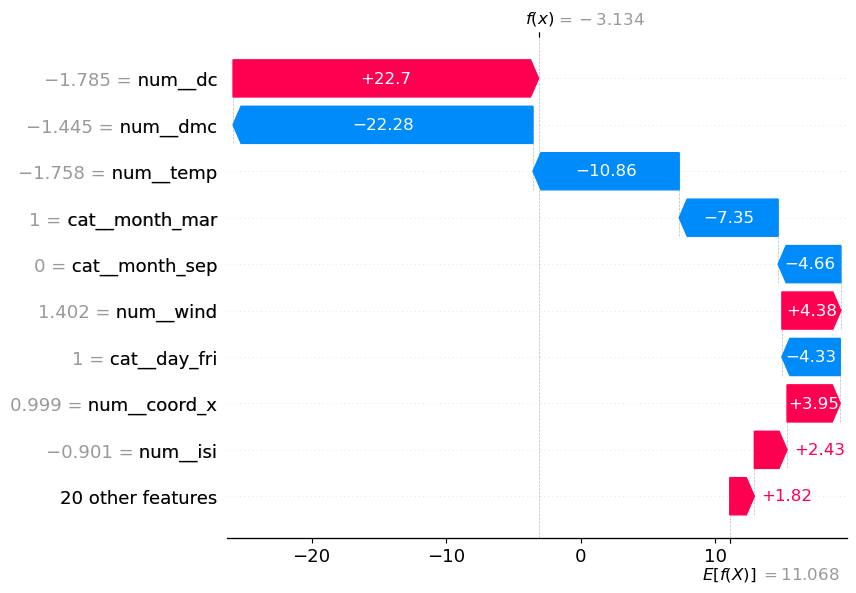

100%|██████████| 100/100 [00:23<00:00,  4.17it/s]


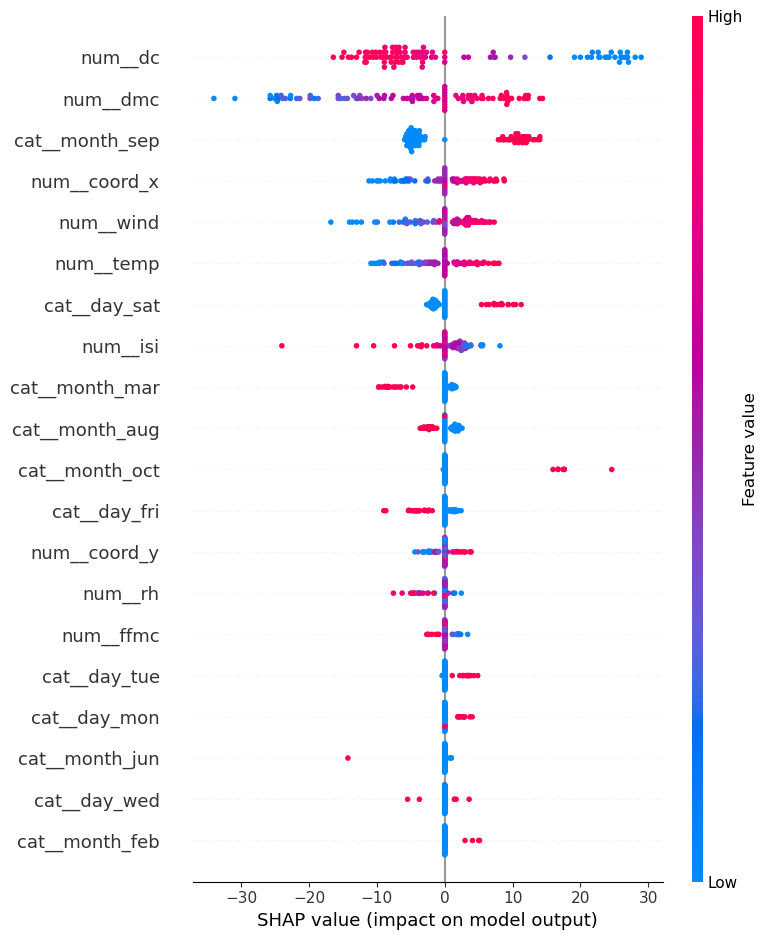

In [ ]:
import shap
import numpy as np

# Assume best_model is pipeline with MLPRegressor
best_model = grid_c.best_estimator_
best_model.fit(X, y)

# Extract preprocessing and model for SHAP input
preprocessor = best_model.named_steps['preprocessing']
model = best_model.named_steps['regressor']

# Preprocess training data
X_preprocessed = preprocessor.transform(X)

# Select a background dataset for 100 random samples
background = shap.sample(X_preprocessed, 100, random_state=42)

explainer = shap.KernelExplainer(model.predict, background)

# Explain a single observation where index 0 is chosen
idx = 0
shap_values = explainer.shap_values(X_preprocessed[idx])

# Plot local explanation (waterfall)
shap.plots.waterfall(shap.Explanation(values=shap_values, 
                                     base_values=explainer.expected_value, 
                                     data=X_preprocessed[idx],
                                     feature_names=preprocessor.get_feature_names_out()))

# Plot global explanation by sampling multiple points and plot summary (beeswarm)
shap_values_all = explainer.shap_values(X_preprocessed[:100])
shap.summary_plot(shap_values_all, X_preprocessed[:100], feature_names=preprocessor.get_feature_names_out())



In [ ]:
#Define function to get feature importance
# Local feature importance for a single observation
idx = 0
shap_values_local = explainer.shap_values(X_preprocessed[idx])
local_df = pd.DataFrame({
    'feature': preprocessor.get_feature_names_out(),
    'shap_value': shap_values_local,
    'abs_shap': np.abs(shap_values_local)
}).sort_values(by='abs_shap', ascending=False)

# Extract top 5 most and least important local features
most_important_local = local_df.head(5)['feature'].tolist()
least_important_local = local_df.tail(5)['feature'].tolist()

# Calculate mean absolute SHAP values for global importance
shap_values_all = explainer.shap_values(X_preprocessed[:100])
shap_array = np.abs(np.array(shap_values_all))  # shape: (100, n_features)
mean_shap = shap_array.mean(axis=0)

global_df = pd.DataFrame({
    'feature': preprocessor.get_feature_names_out(),
    'mean_abs_shap': mean_shap
}).sort_values(by='mean_abs_shap', ascending=False)

# Extract top 5 global features
most_important_global = global_df.head(5)['feature'].tolist()
least_important_global = global_df.tail(5)['feature'].tolist()

# Print results
print("Most Important Local Features:", most_important_local)
print("Least Important Local Features:", least_important_local)
print("Most Important Global Features:", most_important_global)
print("Least Important Global Features:", least_important_global)



100%|██████████| 100/100 [00:23<00:00,  4.19it/s]

Most Important Local Features: ['num__dc', 'num__dmc', 'num__temp', 'cat__month_mar', 'cat__month_sep']
Least Important Local Features: ['cat__day_sat', 'cat__day_sun', 'cat__day_thu', 'cat__day_tue', 'cat__day_wed']
Most Important Global Features: ['num__dc', 'num__dmc', 'cat__month_sep', 'num__coord_x', 'num__wind']
Least Important Global Features: ['cat__day_thu', 'cat__month_dec', 'cat__month_nov', 'cat__month_jan', 'cat__month_may']


*(Answer here.)*
Features with very low SHAP values across all observations should be removed as they likely contribute little to the model's prediction.

The reasons to remove can include: simplify the model for faster training and prediction, easier interpretation, lower risk of overfitting. 

To test, train model with and without those features, drop low-importance features, fit the same model on both using cross-validation, compare performance metrics.

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.